
# Lab 9: Quantun Computing - Rabi Oscillations

Nombre estudiante:

c.c:

## Exercise 1: $NH_3$ molecule

An example of the quantum oscillations in two-level systems may be rather unexpected; for example, the ammonium molecule 

![NH3](../Sesiones/QC/figures/NH3.png)
![NH3](NH3.png)

 It has two symmetric states that differ by the inversion of the nitrogen atom relative to the plane of the three hydrogen atoms, which are weakly coupled due to quantum-mechanical tunneling of the nitrogen atom through the plane of the hydrogen atoms. Since for this particular molecule, in the absence of external fields, the level splitting $\Delta E$ corresponds to an experimentally convenient frequency $\Omega/2\pi\approx$ 24.79 GHz.

 1. Supose a detuning frequency $\Omega_R/2$.
 2. Compute the Rabi frequency for NH3 molecule in Hz and do a plot of the Rabi oscillation. Supose that the initial state is $\ket{2}$.
 
 [see](https://phys.libretexts.org/Bookshelves/Quantum_Mechanics/Essential_Graduate_Physics_-_Quantum_Mechanics_(Likharev)/05%3A_Some_Exactly_Solvable_Problems/5.01%3A_Two-level_Systems)

Frecuencia generalizada (f_R): 24790000000.0 Hz
Frecuencia angular de Rabi (Omega_R): 1.5576e+11 rad/s


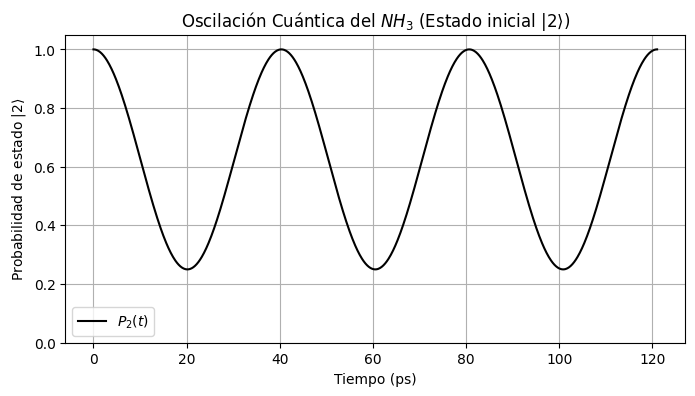

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Cálculo de la frecuencia en Hz
f_R = 24.79e9  # 24.79 GHz en Hz
Omega_R = 2 * np.pi * f_R  # Frecuencia angular generalizada

print(f"Frecuencia generalizada (f_R): {f_R} Hz")
print(f"Frecuencia angular de Rabi (Omega_R): {Omega_R:.4e} rad/s")

# 2. Configuración del tiempo para la gráfica (3 periodos en picosegundos)
T = 1 / f_R
t = np.linspace(0, 3 * T, 1000)

# 3. Cálculo de la probabilidad (Estado inicial |2>)
# Con detuning = Omega_R / 2, la amplitud de transición es 0.75
P_2 = 1 - 0.75 * np.sin(Omega_R * t / 2)**2

# 4. Gráfica
plt.figure(figsize=(8, 4))
plt.plot(t * 1e12, P_2, label=r'$P_2(t)$', color='black')
plt.title('Oscilación Cuántica del $NH_3$ (Estado inicial $|2\\rangle$)')
plt.xlabel('Tiempo (ps)')
plt.ylabel('Probabilidad de estado $|2\\rangle$')
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

## Exercise: Bell state

1. Creates a quantum circuit for two qubits, consisting of the quantum gates needed to create a `Bell state`  (two entangled qubits). The quantum circuit then terminates with quantum measurements, extracting one bit from each qubit.

2. Add a third qubit by changing to QuantumCircuit(3), and add a second CX gate with qc.cx(1,2). The measurements should then change to 000 and 111, which means all three of these qubits have been entangled.

3. See your results shift by adding qc.x(1) to the end of the circuit.

Resultados tras aplicar la compuerta X(1): {'010': 502, '101': 498}


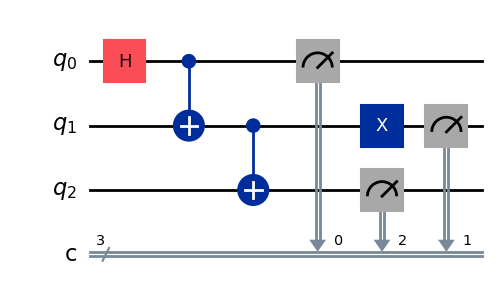

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# ==========================================
# Paso 1: Estado de Bell (2 Qubits)
# ==========================================
qc_bell = QuantumCircuit(2, 2)
qc_bell.h(0)           # Superposición en el qubit 0
qc_bell.cx(0, 1)       # Entrelazamiento (CNOT)
qc_bell.measure([0, 1], [0, 1])

# ==========================================
# Paso 2: Estado Entrelazado GHZ (3 Qubits)
# ==========================================
qc_ghz = QuantumCircuit(3, 3)
qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(1, 2)        # Expande el entrelazamiento al tercer qubit
qc_ghz.measure([0, 1, 2], [0, 1, 2])
# Resultados esperados aquí: ~50% '000' y ~50% '111'

# ==========================================
# Paso 3: Alteración con compuerta X
# ==========================================
qc_final = QuantumCircuit(3, 3)
qc_final.h(0)
qc_final.cx(0, 1)
qc_final.cx(1, 2)
qc_final.x(1)          # Aplica NOT al qubit del medio (q1)
qc_final.measure([0, 1, 2], [0, 1, 2])

# Simulación para validar el comportamiento del paso 3
simulador = AerSimulator()
resultado = simulador.run(qc_final, shots=1000).result()
conteos = resultado.get_counts(qc_final)

print("Resultados tras aplicar la compuerta X(1):", conteos)
qc_final.draw('mpl')